<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/EfficientNetV2B3_Transfer_Learning_Framework_for_Multi_Class_Skin_Lesion_Classification_on_the_PAD_UFES_20_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
train_path = "/content/drive/MyDrive/SkinCancer_Split/train"
test_path  = "/content/drive/MyDrive/SkinCancer_Split/test"

In [3]:
IMG_SIZE = 300
BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes

print(train_generator.class_indices)

Found 1838 images belonging to 6 classes.
Found 460 images belonging to 6 classes.
{'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3, 'SCC': 4, 'SEK': 5}


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5245433789954338), 1: np.float64(0.4531558185404339), 2: np.float64(7.2936507936507935), 3: np.float64(1.570940170940171), 4: np.float64(2.002178649237473), 5: np.float64(1.6294326241134751)}


In [7]:
base_model = EfficientNetV2B3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE,3)
)

base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

inputs = Input(shape=(IMG_SIZE,IMG_SIZE,3))

x = base_model(inputs)

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = Dropout(0.4)(x)

x = Dense(
    128,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation='softmax',
    dtype='float32'
)(x)

model = Model(inputs, outputs)

model.summary()

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,790,148 (52.61 MB)

 Trainable params: 5,352,728 (20.42 MB)

 Non-trainable params: 8,437,420 (32.19 MB)

In [8]:
model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_PAD_UFES20_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [
    early_stop,
    reduce_lr,
    checkpoint
]

In [10]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.2234 - loss: 2.2973 
Epoch 1: val_accuracy improved from None to 0.32174, saving model to best_PAD_UFES20_model.keras

Epoch 1: finished saving model to best_PAD_UFES20_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 1932s 33s/step - accuracy: 0.2639 - loss: 2.1799 - val_accuracy: 0.3217 - val_loss: 1.7443 - learning_rate: 3.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3683 - loss: 1.6530 
Epoch 2: val_accuracy improved from 0.32174 to 0.38043, saving model to best_PAD_UFES20_model.keras

Epoch 2: finished saving model to best_PAD_UFES20_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 844s 14s/step - accuracy: 0.3890 - loss: 1.6441 - val_accuracy: 0.3804 - val_loss: 1.5771 - learning_rate: 3.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4893 - loss: 1.3368 
Epoch 3: val_accuracy improved from 0.38043 to 0.42174, saving model to best_PAD_UFES20_model.keras

Epoch 3: finished saving model

In [11]:
model = tf.keras.models.load_model("best_PAD_UFES20_model.keras")

In [12]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 123s 7s/step - accuracy: 0.6391 - loss: 1.1045
Test Loss : 1.1045
Test Accuracy : 63.91 %


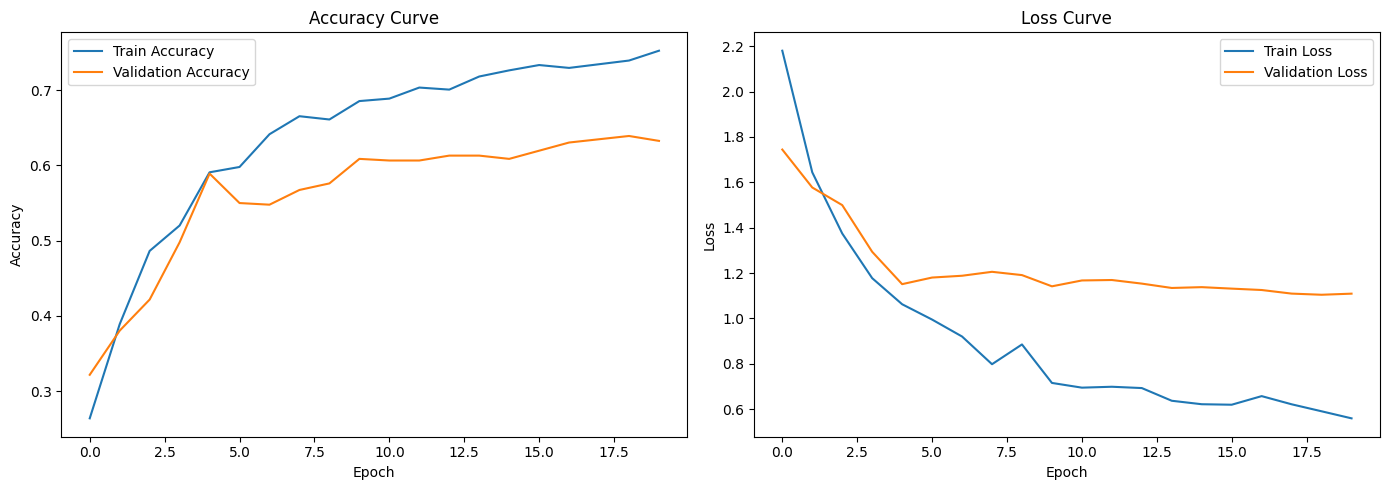

In [13]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

15/15 ━━━━━━━━━━━━━━━━━━━━ 136s 9s/step


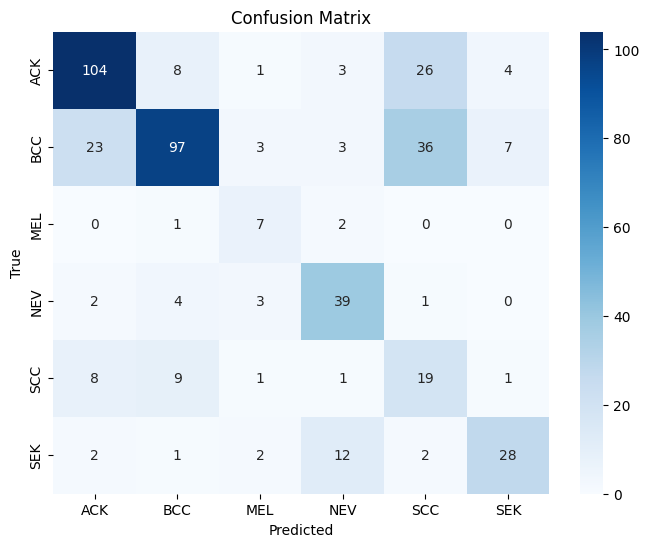

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

         ACK       0.75      0.71      0.73       146
         BCC       0.81      0.57      0.67       169
         MEL       0.41      0.70      0.52        10
         NEV       0.65      0.80      0.72        49
         SCC       0.23      0.49      0.31        39
         SEK       0.70      0.60      0.64        47

    accuracy                           0.64       460
   macro avg       0.59      0.64      0.60       460
weighted avg       0.70      0.64      0.66       460



In [17]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision : {:.2f}%".format(precision*100))
print("Recall    : {:.2f}%".format(recall*100))
print("F1 Score  : {:.2f}%".format(f1*100))

Precision : 70.33%
Recall    : 63.91%
F1 Score  : 65.77%


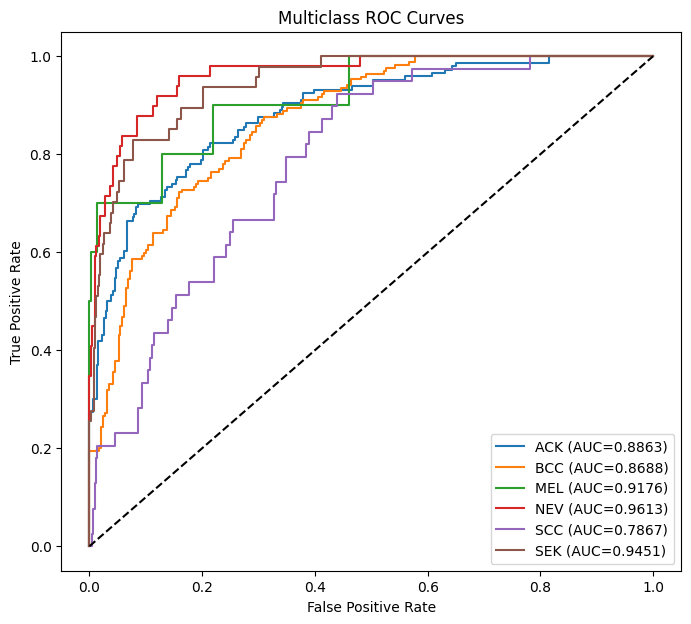

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8,7))

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC={roc_auc[i]:.4f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves')
plt.legend()
plt.show()

In [19]:
print("AUC Values\n")

for i in range(n_classes):

    print(
        class_names[i],
        ":",
        round(roc_auc[i],4)
    )

AUC Values

ACK : 0.8863
BCC : 0.8688
MEL : 0.9176
NEV : 0.9613
SCC : 0.7867
SEK : 0.9451


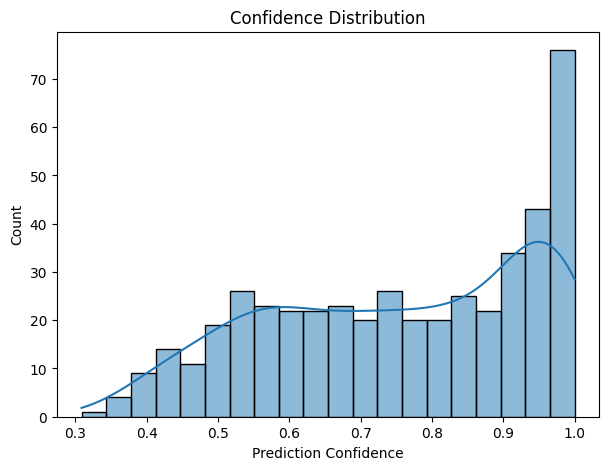

In [20]:
confidence = np.max(
    y_pred_prob,
    axis=1
)

plt.figure(figsize=(7,5))

sns.histplot(
    confidence,
    bins=20,
    kde=True
)

plt.xlabel('Prediction Confidence')
plt.ylabel('Count')
plt.title('Confidence Distribution')
plt.show()

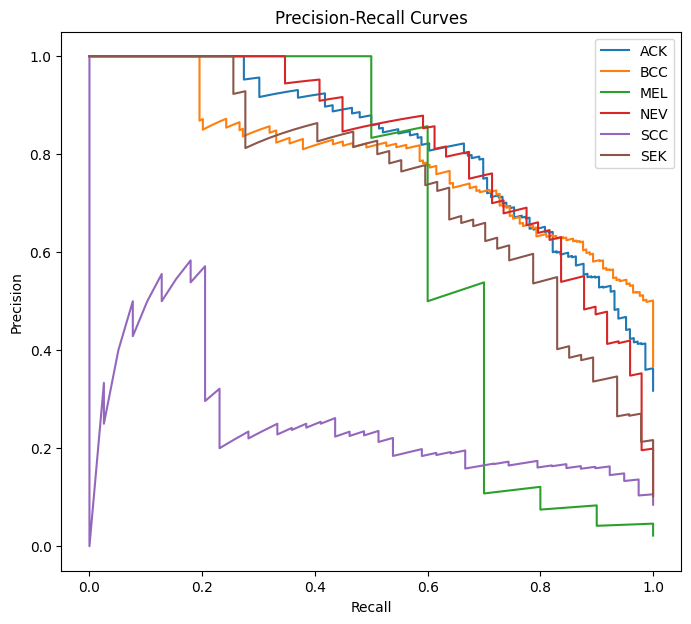

In [21]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,7))

for i in range(n_classes):

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=class_names[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()